# Arquetipos de jugadores NBA por características físicas

## Cargo las librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

## Cargo dos datasets:
* **combine_final.csv**: medidas físicas de jugadores en el NBA Draft Combine (2000–2026). Altura, peso, envergadura, salto, agilidad, etc.
* **nbaplayersdraft_limpio.csv**: historial real de draft y carrera NBA de cada jugador

Por el momento, los datasets no están unidos. Por un lado, el combine solo sabe de medidas y aptitudes físicas. Por otro lado, el NBA Players Draft solo sabe de las estadísticas de jugadores que ya han tenido carrera en la NBA.

In [2]:
# cargo los dos datasets 
combine = pd.read_csv('../../datos/procesados/combine_final.csv')
draft   = pd.read_csv('../../datos/procesados/nbaplayersdraft_limpio.csv')

# muestro información de los datasets
print('=== COMBINE (medidas físicas) ===')
print(f'Filas: {combine.shape[0]} jugadores   |   Columnas: {combine.shape[1]}')
print()
print('=== DRAFT HISTÓRICO (carrera NBA) ===')
print(f'Filas: {draft.shape[0]} jugadores   |   Columnas: {draft.shape[1]}')

=== COMBINE (medidas físicas) ===
Filas: 1873 jugadores   |   Columnas: 18

=== DRAFT HISTÓRICO (carrera NBA) ===
Filas: 1922 jugadores   |   Columnas: 23


## Trabajo de variables:

El combine recoge muchas medidas, pero no todas son igual de útiles ni están disponibles para todos los jugadores. Por eso hago tres cosas:

1. **Selecciono las 7 variables físicas más relevantes**: altura, peso, envergadura, alcance en pie, salto máximo, tiempo de agilidad y velocidad en sprint. Son las que mejor definen el perfil físico de un jugador.

2. **Elimino los ceros**: en este dataset un valor 0 no significa "cero real", sino que esa medida no se tomó. Los trato como nulos y elimino esas filas.

3. **Me quedo con una sola entrada por jugador**: algunos jugadores fueron al combine más de un año. Me quedo con la entrada más reciente, que es la más representativa.

Al final obtengo un dataset limpio donde cada fila es un jugador único con todas sus medidas físicas disponibles.

In [3]:
# selecciono las 7 medidas físicas más relevantes y fiables del combine
# son las que mejor describen el perfil físico de un jugador
VARIABLES = [
    'HEIGHT_W_SHOES',       # altura con zapatillas
    'WEIGHT',               # peso
    'WINGSPAN',             # envergadura
    'STANDING_REACH',       # alcance en pie (altura con el brazo extendido)
    'MAX_VERTICAL_LEAP',    # salto máximo
    'LANE_AGILITY_TIME',    # tiempo en circuito de agilidad (menos = más ágil)
    'THREE_QUARTER_SPRINT', # tiempo en sprint de 3/4 de pista (menos = más rápido)
]

# me quedo solo con las columnas que necesito
combine_clustering = combine[['SEASON', 'PLAYER_NAME', 'POSITION'] + VARIABLES].copy()

# elimino filas donde alguna medida sea 0 — en este dataset el 0 significa "no medido"
# no es un cero real, es un valor faltante codificado así
combine_clustering = combine_clustering[(combine_clustering[VARIABLES] > 0).all(axis=1)]

# si un jugador fue al combine varios años, me quedo solo con su entrada más reciente
# así cada jugador aparece una sola vez
combine_clustering = combine_clustering.drop_duplicates(subset='PLAYER_NAME', keep='last')

# normalizo el nombre aquí para poder usarlo en todo el notebook
combine_clustering['nombre_norm'] = combine_clustering['PLAYER_NAME'].str.lower().str.strip()

print(f'Jugadores válidos para el clustering: {len(combine_clustering)}')
print()
print('Estadísticas descriptivas de las medidas físicas:')
combine_clustering[VARIABLES].describe().round(2)

Jugadores válidos para el clustering: 1802

Estadísticas descriptivas de las medidas físicas:


,HEIGHT_W_SHOES,WEIGHT,WINGSPAN,STANDING_REACH,MAX_VERTICAL_LEAP,LANE_AGILITY_TIME,THREE_QUARTER_SPRINT
count,1802.00,1802.00,1802.00,1802.00,1802.00,1802.00,1802.00
mean,78.86,215.07,82.38,103.55,34.62,11.37,3.27
std,2.66,25.60,3.94,4.80,3.43,0.53,0.12
min,69.00,149.20,70.00,88.50,21.00,9.65,2.87
25%,78.00,196.80,79.81,100.00,32.50,11.02,3.20
50%,79.00,213.20,82.50,104.00,34.50,11.30,3.26
75%,80.00,232.00,85.00,107.00,36.50,11.62,3.33
max,91.00,334.00,98.25,122.50,48.00,14.45,3.81


## Método del codo: ¿Cuántos arquetipos creo?

KMeans necesita que le digamos de antemano cuántos grupos queremos crear. Para elegir ese número de forma objetiva usamos el **método del codo**.

La idea es sencilla: probamos KMeans con distintos números de grupos (de 2 a 12) y medimos la **inercia** en cada caso. La inercia mide qué tan lejos están los jugadores de su centroide. Es decir, cuanto más baja, más compactos y homogéneos son los grupos.

El problema es que más grupos siempre significa menos inercia. El truco está en buscar el punto donde añadir un grupo más deja de mejorar mucho la inercia. Por tanto, ese "codo" en la gráfica es el número óptimo.

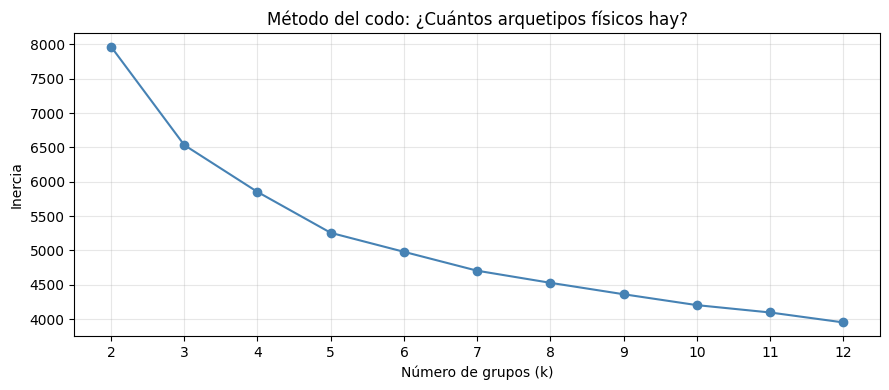

In [4]:
# estandarizo las variables antes de clustering
# necesario porque las unidades son muy distintas:
# el peso está en libras (~200), el tiempo de sprint en segundos (~3)
# sin escalar, KMeans daría más importancia a las variables con números más grandes
scaler = StandardScaler()
X = scaler.fit_transform(combine_clustering[VARIABLES])

# pruebo KMeans con distintos números de grupos y guardo la inercia de cada uno
inercias = []
k_range = range(2, 13)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=11, n_init=10)
    km.fit(X)
    inercias.append(km.inertia_)

# visualizo el codo
plt.figure(figsize=(9, 4))
plt.plot(k_range, inercias, 'o-', color='steelblue')
plt.xlabel('Número de grupos (k)')
plt.ylabel('Inercia')
plt.title('Método del codo: ¿Cuántos arquetipos físicos hay?')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretación

La gráfica muestra cómo cae la inercia a medida que aumentamos el número de grupos.

Se pueden ver dos tramos claros:

- **De 2 a 5 grupos**: la inercia cae con fuerza — cada grupo nuevo aporta mucho
- **A partir de 7**: la curva se aplana — añadir más grupos apenas mejora nada

El codo más claro está en **k=7**, que es el punto donde la mejora empieza a ser marginal. Por eso entreno el KMeans con 7 grupos, que en este contexto representan **7 arquetipos físicos distintos** de jugador NBA.

## Entrenamiento KMeans

Entreno el modelo con el número de clusters elegido en el codo (K=7).

KMeans agrupa a los jugadores de forma que los del mismo grupo se parezcan físicamente entre sí y sean distintos a los de otros grupos. Al final cada jugador tiene asignado un número de cluster (0 a 6).

In [5]:
# defino el número de clusters
K = 7

# defino el modelo KMeans
km = KMeans(n_clusters=K, random_state=11, n_init=10)

# fit_predict entrena el modelo Y asigna el cluster a cada jugador en un solo paso
# el resultado es una columna nueva con un número del 0 al 6
combine_clustering['cluster'] = km.fit_predict(X)

# compruebo cuántos jugadores hay en cada cluster
# si algún grupo tiene muy pocos jugadores puede ser señal de un outlier o de que K es demasiado alto
print('Jugadores por cluster:')
print(combine_clustering['cluster'].value_counts().sort_index())

Jugadores por cluster:
cluster
0    162
1    418
2    245
3    181
4    283
5    296
6    217
Name: count, dtype: int64


## Evaluación del modelo: Silhouette Score

El **Silhouette Score** mide qué tan bien separados están los grupos. Es la métrica estándar para evaluar clustering.

Para cada jugador calcula dos cosas:
- **a**: la distancia media a los jugadores de su mismo grupo (cohesión).
- **b**: la distancia media al grupo más cercano (separación).

El resultado es un número entre -1 y 1:
- **Cerca de 1**: los grupos están bien separados y son compactos
- **Cerca de 0**: los grupos se solapan
- **Negativo**: muchos jugadores están mal asignados

Un valor por encima de 0.5 se considera aceptable para datos reales.

In [6]:
from sklearn.metrics import silhouette_score

# calculo el silhouette score sobre los datos escalados
# uso X que ya tiene las 7 variables estandarizadas
score = silhouette_score(X, combine_clustering['cluster'])

print(f'Silhouette Score: {score:.4f}')

Silhouette Score: 0.1608


## Interpretación

El resultado obtenido es **0.1608**, que es bajo pero esperado en este contexto. Y hay tres razones que explican este número:

1. **Los arquetipos físicos de jugadores NBA se solapan por naturaleza**: no existe una frontera física clara entre un "Base explosivo" y un "Alero atlético".

2. **Usamos 7 dimensiones**: el Silhouette Score tiende a ser más bajo en espacios de alta dimensionalidad.

3. **El objetivo del clustering aquí no es separación perfecta, sino utilidad práctica**.

## Otra manera de comprobar si los grupos están bien separados: **PCA**

KMeans ha creado 7 grupos basándose en 7 variables físicas. Pero, ¿cómo sabemos si los grupos tienen sentido? Necesitamos visualizarlos. El problema es que no podemos pintar 7 dimensiones en una gráfica. Para ello uso **PCA (Análisis de Componentes Principales)**. De esta manera, se comprimen las 7 variables en 2 nuevas variables artificiales llamadas **componentes**, conservando la mayor cantidad de información posible.

El PCA no forma parte del modelo. Solo sirve para visualizar. KMeans trabaja con las 7 variables originales, no con los 2 componentes.


In [7]:
# comprimo las 7 variables a 2 componentes para poder visualizar los grupos
pca = PCA(n_components=2, random_state=11)
coordenadas = pca.fit_transform(X)

# guardo las coordenadas PCA en el dataframe para usarlas en la gráfica
combine_clustering['pca1'] = coordenadas[:, 0]
combine_clustering['pca2'] = coordenadas[:, 1]

## ¿Cuánta información se conserva?

Antes de ver la gráfica, compruebo cuánta información del dataset original conservan los 2 componentes.El porcentaje de varianza explicada nos dice qué tan fiable es la visualización. Si los 2 componentes juntos explican un alto porcentaje, esto significa que se conserva gran parte de la información original.

La información perdida (el porcentaje restante) es el precio que se paga por poder visualizar datos de 7 dimensiones en 2D.

In [8]:
# muestro cuánta varianza explica cada componente por separado
for i, varianza in enumerate(pca.explained_variance_ratio_):
    print(f"Componente {i+1}: {varianza*100:.1f}% de la varianza")

print(f"\nTotal explicado: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Información perdida: {(1 - pca.explained_variance_ratio_.sum())*100:.1f}%")

Componente 1: 57.5% de la varianza
Componente 2: 17.3% de la varianza

Total explicado: 74.8%
Información perdida: 25.2%


## Visualización de los grupos en 2D

Pinto cada jugador en el plano de los 2 componentes PCA, coloreando por grupo. Los ejes muestran el porcentaje de varianza original que explica cada componente.

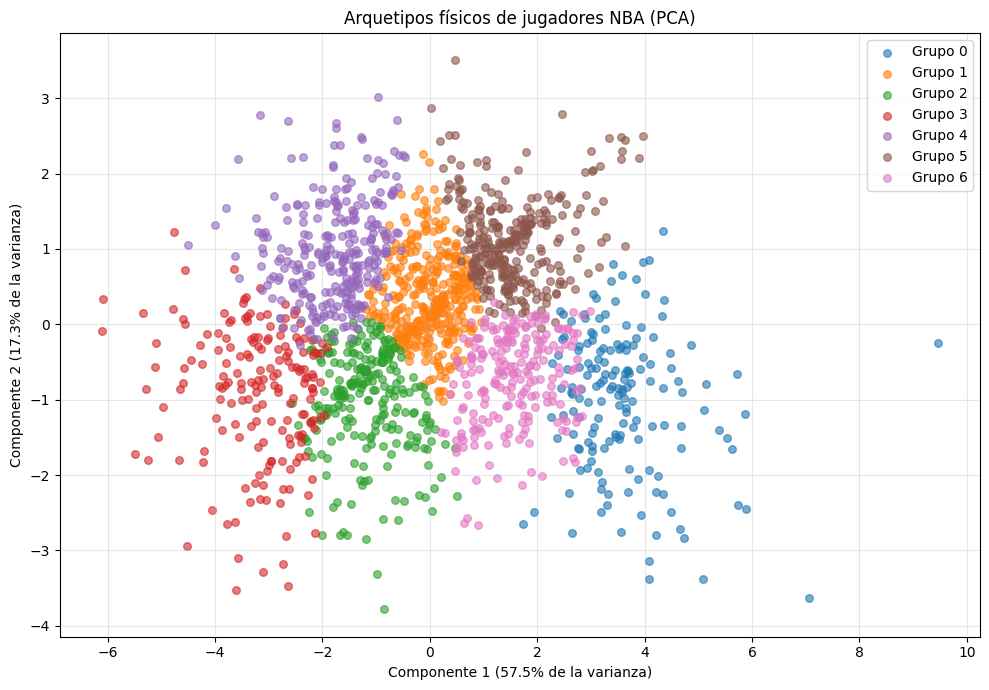

In [9]:
# pinto cada grupo con un color distinto
plt.figure(figsize=(10, 7))
for c in range(K):
    mascara = combine_clustering['cluster'] == c
    plt.scatter(
        combine_clustering.loc[mascara, 'pca1'],
        combine_clustering.loc[mascara, 'pca2'],
        label=f'Grupo {c}',
        alpha=0.6,
        s=30
    )

# en el eje pongo cuánta varianza original explica cada componente
plt.xlabel(f'Componente 1 ({pca.explained_variance_ratio_[0]*100:.1f}% de la varianza)')
plt.ylabel(f'Componente 2 ({pca.explained_variance_ratio_[1]*100:.1f}% de la varianza)')
plt.title('Arquetipos físicos de jugadores NBA (PCA)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretación

Parece que los grupos aparecen bien separados y con poca mezcla entre ellos. Esto es síntoma de que el clustering está funcionando correctamente, ya que hay jugadores físicamente similares están agrupados juntos.

¡IMPORTANTE! Esto no es el modelo. Es solo una fotografía en 2D de algo que ocurre en 7 dimensiones.

## Análisis de centroides: ¿qué perfil físico tiene cada grupo?

El **centroide** es el punto central de cada grupo — representa al jugador físicamente "promedio" de ese arquetipo. Analizando sus medidas podemos entender qué tipo de jugador hay en cada grupo y ponerle un nombre descriptivo.

Para comparar los grupos entre sí uso un **heatmap normalizado**: convierto todos los valores a una escala de 0 a 1, donde:

* **Rojo oscuro**: valor por encima de esa medida
* **Amarillo**: valor por debajo de esa medida

¡Ojo con las variables de tiempo! 'LANE_AGILITY_TIME' y 'THREE_QUARTER_SPRINT' implican que **menos es mejor**, ya que un jugador más rápido tendrá un valor más bajo y, por tanto, aparecerá en amarillo aunque eso sea una ventaja.

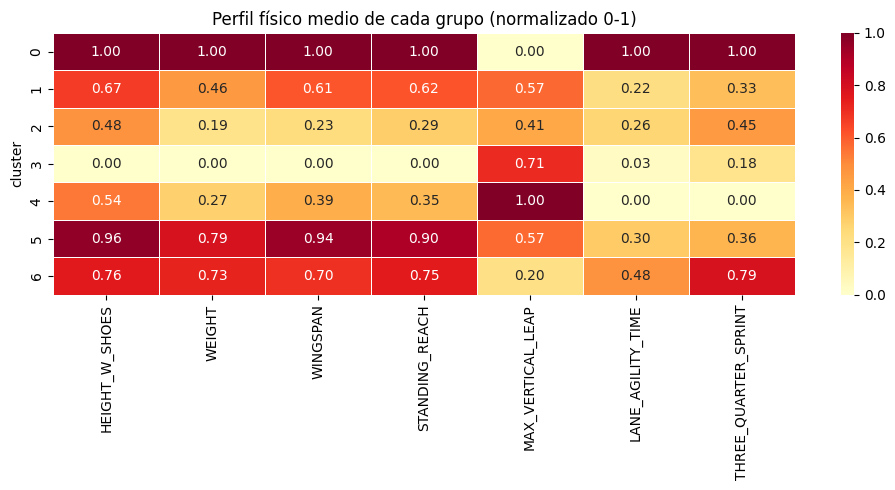

In [10]:
# calculo el centroide de cada grupo — la media de cada variable física por grupo
centroides = combine_clustering.groupby('cluster')[VARIABLES].mean().round(2)

# normalizo los centroides de 0 a 1 para que sean comparables entre sí
# sin normalizar no podría comparar peso (~200 libras) con tiempo de sprint (~3 segundos)
centroides_norm = (centroides - centroides.min()) / (centroides.max() - centroides.min())

# heatmap de centroides normalizados
plt.figure(figsize=(10, 5))
sns.heatmap(centroides_norm, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Perfil físico medio de cada grupo (normalizado 0-1)')
plt.tight_layout()
plt.show()

## Interpretación

| Grupo | Perfil físico | Arquetipo probable |
|-------|--------------|-------------------|
| **0** | Máximo en altura, peso, envergadura y alcance. Salto bajo, lento | Pívot clásico |
| **1** | Medidas medias-altas en todo. Equilibrado | Alero / Escolta versátil |
| **2** | Talla baja, poco peso. Salto medio | Base / Escolta pequeño |
| **3** | El más pequeño y ligero de todos. Salto alto, muy rápido | Base / Escolta explosivo |
| **4** | Talla media-alta. **Salto más alto de todos** (1.00). El más ágil y veloz | Alero atlético explosivo |
| **5** | Casi tan alto como el grupo 0 pero más ágil. Envergadura enorme | Pívot élite moderno |
| **6** | Alto y pesado pero con peor agilidad y sprint — el más lento | Alero / Escolta duro |

¡IMPORTANTE! En 'LANE_AGILITY_TIME' y 'THREE_QUARTER_SPRINT' el amarillo significa **más rápido**, no peor. El grupo 4 con 0.00 en ambas es el más veloz del dataset.

## Guardado de archivos

Guardo los tres elementos necesarios para poder reutilizar el clustering sin tener que reentrenar:

- **KMeans**: el modelo que asigna un grupo a cada jugador
- **Scaler**: la estandarización que se aplicó antes del clustering
- **PCA**: la reducción de dimensionalidad para visualizar

Es importante guardar los tres juntos. Si más adelante quiero predecir el arquetipo de un jugador nuevo, necesito escalar sus medidas con el mismo scaler y proyectarlas con el mismo PCA antes de pasárselas al KMeans.

In [11]:
os.makedirs('../pkl/modelos', exist_ok=True)
os.makedirs('../pkl/preprocesado', exist_ok=True)

joblib.dump(km,     '../pkl/modelos/kmeans_arquetipos.pkl')
joblib.dump(scaler, '../pkl/preprocesado/scaler_combine.pkl')
joblib.dump(pca,    '../pkl/preprocesado/pca_combine.pkl')

print("Modelos guardados")

Modelos guardados


## Unión del combine con el historial NBA

Hasta aquí tenemos los grupos físicos creados, pero también quiero unir el arquetipo con varios jugadores que lo definan. Para ello uno el combine con el historial real de draft.

El cruce se hace por nombre de jugador. Para evitar errores por mayúsculas o espacios, normalizo los nombres de los dos datasets a minúsculas antes de hacer el merge.

Uso un `inner join`, con lo que solo me quedo con los jugadores que aparecen en **los dos datasets a la vez**: fueron al combine y tienen historial NBA. Los que fueron al combine pero no llegaron a la NBA desaparecen aquí. A partir de este punto 'combine_merge' no representa a todos los jugadores del combine, sino solo a los que tuvieron carrera NBA real.

In [12]:
# normalizo nombres del draft en minúsculas para evitar errores en el cruce

draft['nombre_norm'] = draft['player'].str.lower().str.strip()

# uno los dos datasets por nombre de jugador
# inner join con solo jugadores que están en los dos datasets a la vez
combine_merge = combine_clustering.merge(draft, on='nombre_norm', how='inner')

print(f'Jugadores en el combine:                {len(combine_clustering)}')
print(f'Jugadores en el historial NBA:          {len(draft)}')
print(f'Jugadores con combine + carrera NBA:    {len(combine_merge)}')

Jugadores en el combine:                1802
Jugadores en el historial NBA:          1922
Jugadores con combine + carrera NBA:    822


## Estadísticas medias por arquetipo

Ahora que tengo el combine unido al historial NBA, puedo calcular qué carrera tuvo de media cada arquetipo físico. Filtro primero los jugadores con al menos 1 temporada real en la NBA, con lo que puedo eliminar a los que fueron drafteados pero nunca llegaron a jugar.

El resultado me permite responder preguntas como: ¿qué arquetipo físico tiende a durar más en la NBA? ¿cuál anota más? ¿cuál rebotea más?

In [13]:
# filtro solo jugadores con carrera NBA real (al menos 1 temporada jugada)
jugadores_activos = combine_merge[combine_merge['years_active'] >= 1].copy()

# calculo la media de las estadísticas principales por grupo
# nota: en este punto aún no tenemos los nombres de arquetipos — los asignamos en la siguiente celda
stats_por_arquetipo = jugadores_activos.groupby('cluster')[
    ['points_per_game', 'average_total_rebounds', 'average_assists', 'years_active']
].mean().round(2)

# ordeno por puntos por partido para ver qué arquetipo rinde más ofensivamente
stats_por_arquetipo = stats_por_arquetipo.sort_values('points_per_game', ascending=False)

stats_por_arquetipo

,points_per_game,average_total_rebounds,average_assists,years_active
cluster,,,,
3,8.26,1.95,2.88,6.29
1,8.09,3.23,1.50,5.66
4,7.88,2.50,1.75,5.38
2,7.13,2.03,2.16,5.10
0,6.66,4.35,0.85,6.68
5,6.66,4.08,0.91,5.73
6,6.37,3.39,1.10,7.16


## Nombres de los arquetipos

Ahora sí tiene sentido poner nombres a cada grupo.

In [14]:
# asigno nombres a cada grupo basándome en el heatmap
NOMBRES_GRUPOS = {
    0: 'Pívot clásico',
    1: 'Alero / Escolta versátil',
    2: 'Base / Escolta pequeño',
    3: 'Base / Escolta explosivo',
    4: 'Alero atlético explosivo',
    5: 'Pívot élite moderno',
    6: 'Alero / Escolta duro',
}

combine_clustering['arquetipo'] = combine_clustering['cluster'].map(NOMBRES_GRUPOS)
combine_merge['arquetipo']      = combine_merge['cluster'].map(NOMBRES_GRUPOS)

print("Arquetipos asignados:")
for c, nombre in NOMBRES_GRUPOS.items():
    print(f"  Grupo {c}: {nombre}")

Arquetipos asignados:
  Grupo 0: Pívot clásico
  Grupo 1: Alero / Escolta versátil
  Grupo 2: Base / Escolta pequeño
  Grupo 3: Base / Escolta explosivo
  Grupo 4: Alero atlético explosivo
  Grupo 5: Pívot élite moderno
  Grupo 6: Alero / Escolta duro


## Jugadores de referencia por arquetipo

Asigno a mano una lista de jugadores NBA conocidos que representan bien cada arquetipo.

In [15]:
# jugadores de referencia por arquetipo — elegidos a mano tras validar el merge
# las claves deben coincidir exactamente con los valores de NOMBRES_GRUPOS
REFERENTES = {
    'Pívot clásico':            ['Dwight Howard', 'DeAndre Jordan', 'Boban Marjanovic', 'Rudy Gobert', "Shaquille O'Neal"],
    'Alero / Escolta versátil': ['Kevin Love', 'LaMarcus Aldridge', 'Blake Griffin', 'Draymond Green', 'Tobias Harris'],
    'Base / Escolta pequeño':   ['Chris Paul', 'Isaiah Thomas', 'Kemba Walker', 'Trae Young', 'Kyle Lowry'],
    'Base / Escolta explosivo': ['Ja Morant', "De'Aaron Fox", 'John Wall', 'Russell Westbrook', 'Derrick Rose'],
    'Alero atlético explosivo': ['Giannis Antetokounmpo', 'LeBron James', 'Zion Williamson', 'Donovan Mitchell', 'Jaylen Brown'],
    'Pívot élite moderno':      ['Anthony Davis', 'Bam Adebayo', 'Joel Embiid', 'Nikola Jokic', 'Karl-Anthony Towns'],
    'Alero / Escolta duro':     ['Ron Artest', 'Carmelo Anthony', 'Rudy Gay', 'DeMar DeRozan', 'Paul Pierce'],
}

print("Jugadores de referencia por arquetipo:")
print("=" * 55)
for arquetipo, jugadores in REFERENTES.items():
    print(f"\n{arquetipo}:")
    for j in jugadores:
        print(f"  • {j}")

Jugadores de referencia por arquetipo:

Pívot clásico:
  • Dwight Howard
  • DeAndre Jordan
  • Boban Marjanovic
  • Rudy Gobert
  • Shaquille O'Neal

Ala-Pívot versátil:
  • Kevin Love
  • LaMarcus Aldridge
  • Blake Griffin
  • Draymond Green
  • Tobias Harris

Base / Escolta pequeño:
  • Chris Paul
  • Isaiah Thomas
  • Kemba Walker
  • Trae Young
  • Kyle Lowry

Base explosivo:
  • Ja Morant
  • De'Aaron Fox
  • John Wall
  • Russell Westbrook
  • Derrick Rose

Alero atlético explosivo:
  • Giannis Antetokounmpo
  • LeBron James
  • Zion Williamson
  • Donovan Mitchell
  • Jaylen Brown

Pívot élite moderno:
  • Anthony Davis
  • Bam Adebayo
  • Joel Embiid
  • Nikola Jokic
  • Karl-Anthony Towns

Alero / Escolta duro:
  • Ron Artest
  • Carmelo Anthony
  • Rudy Gay
  • DeMar DeRozan
  • Paul Pierce


## Función principal: buscar el arquetipo de un jugador

Esta función es el núcleo del notebook. Dado el nombre de cualquier jugador que aparezca en el combine, me devuelve:

1. **Arquetipo**: grupo físico al que pertenece.
2. **Medidas físicas**: altura, peso, envergadura o salto.
3. **Jugadores de referencia**.

In [16]:
from sklearn.metrics.pairwise import euclidean_distances

def buscar_arquetipo(nombre_jugador):

    # busco al jugador en el combine por nombre exacto o parcial
    nombre_norm = nombre_jugador.lower().strip()
    coincidencia = combine_clustering[combine_clustering['nombre_norm'] == nombre_norm]

    if coincidencia.empty:
        coincidencia = combine_clustering[combine_clustering['nombre_norm'].str.contains(nombre_norm, na=False)]
        if coincidencia.empty:
            print(f"Jugador '{nombre_jugador}' no encontrado en el combine.")
            return

    jugador = coincidencia.iloc[0]
    cluster_id = jugador['cluster']
    arquetipo  = jugador['arquetipo']

    print(f"\n{'='*60}")
    print(f"Jugador          : {jugador['PLAYER_NAME']}")
    print(f"Temporada combine: {jugador['SEASON']}")
    print(f"Posición         : {jugador['POSITION']}")
    print(f"Arquetipo        : {arquetipo}")
    print(f"{'='*60}")

    # muestro sus medidas físicas
    print("\nMedidas físicas:")
    for variable in VARIABLES:
        print(f"  {variable}: {jugador[variable]:.2f}")

    # muestro los jugadores de referencia de ese arquetipo
    referentes = REFERENTES.get(arquetipo, [])
    if referentes:
        print(f"\nJugadores NBA de referencia para este arquetipo:")
        for r in referentes:
            print(f"  • {r}")

# prueba con Aday Mara
buscar_arquetipo('Aday Mara')


Jugador          : Aday Mara
Temporada combine: 2026
Posición         : C
Arquetipo        : Pívot clásico

Medidas físicas:
  HEIGHT_W_SHOES: 79.00
  WEIGHT: 259.80
  WINGSPAN: 90.00
  STANDING_REACH: 117.00
  MAX_VERTICAL_LEAP: 28.00
  LANE_AGILITY_TIME: 11.47
  THREE_QUARTER_SPRINT: 3.61

Jugadores NBA de referencia para este arquetipo:
  • Dwight Howard
  • DeAndre Jordan
  • Boban Marjanovic
  • Rudy Gobert
  • Shaquille O'Neal


## Pruebo la función con el nombre de un jugador

In [17]:
buscar_arquetipo('Dylan Harper')


Jugador          : Dylan Harper
Temporada combine: 2025
Posición         : PG-SG
Arquetipo        : Alero / Escolta versátil

Medidas físicas:
  HEIGHT_W_SHOES: 79.00
  WEIGHT: 213.20
  WINGSPAN: 82.50
  STANDING_REACH: 102.00
  MAX_VERTICAL_LEAP: 36.50
  LANE_AGILITY_TIME: 11.07
  THREE_QUARTER_SPRINT: 3.16


## Predicción manual de arquetipo

Para jugadores que no pasaron por el combine, o simplemente para probar, puedo introducir las medidas físicas a mano y obtener su arquetipo directamente.

In [18]:
# introduce aquí el nombre y las medidas físicas del jugador
# puedes usar centímetros, kilos y centímetros para el salto — el código convierte solo
nombre_jugador = 'Roberto Cantero'

medidas_manuales_metrico = {
    'HEIGHT_W_SHOES'      : 188.0,  # altura con zapatillas (cm)
    'WEIGHT'              : 86.0,   # peso (kg)
    'WINGSPAN'            : 190.0,  # envergadura (cm)
    'STANDING_REACH'      : 250.0,  # alcance en pie (cm)
    'MAX_VERTICAL_LEAP'   : 50.0,   # salto máximo (cm)
    'LANE_AGILITY_TIME'   : 10.5,   # tiempo agilidad (segundos — menos es mejor)
    'THREE_QUARTER_SPRINT': 4.4,    # tiempo sprint (segundos — menos es mejor)
}

# convierto al sistema imperial que usa el combine
medidas_manuales = {
    'HEIGHT_W_SHOES'      : medidas_manuales_metrico['HEIGHT_W_SHOES']        / 2.54,
    'WEIGHT'              : medidas_manuales_metrico['WEIGHT']                 * 2.205,
    'WINGSPAN'            : medidas_manuales_metrico['WINGSPAN']               / 2.54,
    'STANDING_REACH'      : medidas_manuales_metrico['STANDING_REACH']        / 2.54,
    'MAX_VERTICAL_LEAP'   : medidas_manuales_metrico['MAX_VERTICAL_LEAP']     / 2.54,
    'LANE_AGILITY_TIME'   : medidas_manuales_metrico['LANE_AGILITY_TIME'],
    'THREE_QUARTER_SPRINT': medidas_manuales_metrico['THREE_QUARTER_SPRINT'],
}

# construyo el vector y lo escalo con el mismo scaler del modelo
vector = pd.DataFrame([medidas_manuales])
vector_escalado = scaler.transform(vector)

# predigo el cluster y obtengo el arquetipo
cluster_id = km.predict(vector_escalado)[0]
arquetipo  = NOMBRES_GRUPOS[cluster_id]

print(f"\n{'='*60}")
print(f"Jugador  : {nombre_jugador}")
print(f"Arquetipo: {arquetipo}")
print(f"{'='*60}")

# referentes de ese arquetipo
referentes = REFERENTES.get(arquetipo, [])
if referentes:
    print(f"\nJugadores NBA de referencia:")
    for r in referentes:
        print(f"  • {r}")


Jugador  : Roberto Cantero
Arquetipo: Alero / Escolta duro

Jugadores NBA de referencia:
  • Ron Artest
  • Carmelo Anthony
  • Rudy Gay
  • DeMar DeRozan
  • Paul Pierce
